## Machine Learning Essentials Exercise 1
### 1 Exploring the Data

In [145]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])
Images size: (1797, 8, 8)


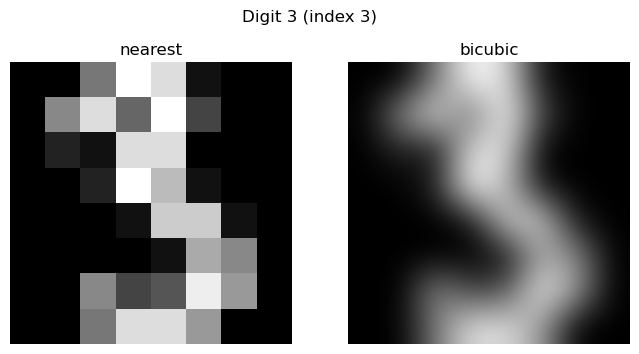

In [146]:
# load the dataset
digits = load_digits()

print(digits.keys())

# eX_trainacts data, images, target, target_names
data = digits['data']
images = digits['images']
target = digits['target']
target_names = digits['target_names']

# size of the images
images_size = images.shape

print(f'Images size: {images_size}')

# visualize one image of a 3
# find an idx where target == 3
digit = 3
idx = np.where(target == digit)[0][0] # returns the first index where target is matched
img = images[idx]

# check if img is a 2-D array
assert 2 == len(img.shape), 'The image is not a 2-D array'

# plot with the two interpolation methods('nearest' and 'bicubic')
plt.figure(figsize=(8, 4))
plt.gray()

plt.subplot(1, 2, 1)
plt.imshow(img, interpolation='nearest')
plt.title('nearest')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img, interpolation='bicubic')
plt.title('bicubic')
plt.axis('off')

plt.suptitle(f'Digit {digit} (index {idx})')
plt.show()

# filter the dataset for '3' and '9'
mask = np.isin(target, [3, 9])

data_39 = data[mask]
target_39 = target[mask]

# split the filtered dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(
    data_39,
    target_39,
    test_size=0.4,
    random_state=0,
    stratify=target_39
)


### 2 Hand-crafted classifier

#### 2.1 Feature Construction

In [147]:
def features2d(X_train, y_train):
    # select the images that are 3 and 9
    mask3 = np.isin(y_train, 3)
    mask9 = np.isin(y_train, 9)

    img3s = X_train[mask3]
    img9s = X_train[mask9]

    # find the average of each pixel across all images
    avg_img3s = img3s.mean(axis=0)
    avg_img9s = img9s.mean(axis=0)

    diff = np.abs(avg_img3s - avg_img9s)

    # find the two pixels position (indices) with biggest difference
    best_pixels_idx = np.argsort(diff)[::-1]
    best_idx1 = best_pixels_idx[0]
    best_idx2 = best_pixels_idx[1]

    f1 = X_train[:, best_idx1]
    f2 = X_train[:, best_idx2]

    features = np.column_stack([f1, f2])
    
    return features
    
# build features for the training and test sets
training_features = features2d(X_train, y_train)
test_features = features2d(X_test, y_test)

#### 2.2 Scatter plot

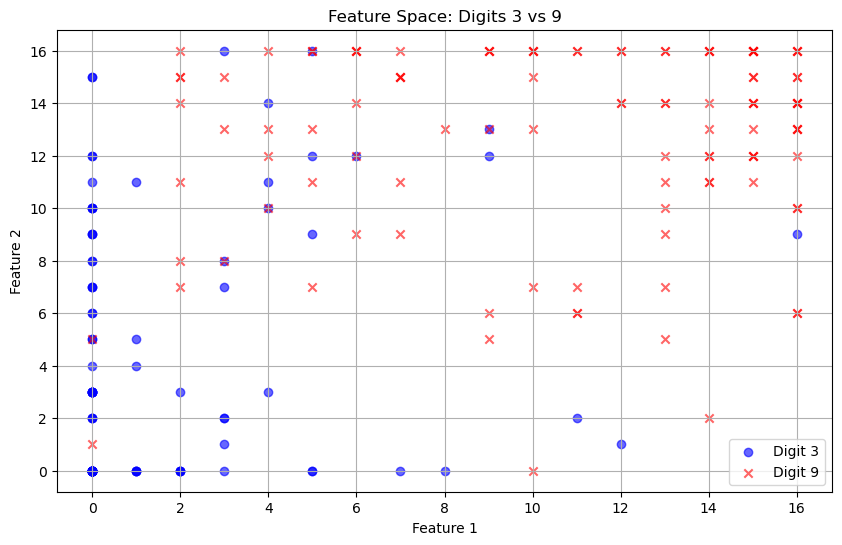

In [148]:
plt.figure(figsize=(10, 6))

# separate features by class
mask3 = np.isin(y_train, 3)
mask9 = np.isin(y_train, 9)

f1_train3 = training_features[mask3, 0]
f2_train3 = training_features[mask3, 1]
f1_train9 = training_features[mask9, 0]
f2_train9 = training_features[mask9, 1]

plt.scatter(f1_train3, f2_train3, label='Digit 3', alpha=0.6, marker='o', color='blue')
plt.scatter(f1_train9, f2_train9, label='Digit 9', alpha=0.6, marker='x', color='red')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Feature Space: Digits 3 vs 9')
plt.legend()
plt.grid()
plt.show()


#### 2.3 Decision rule

In [149]:
def nearest_mean(training_features, training_labels,  test_features):
    # find  the mean for 3 and 9
    mask3 = np.isin(training_labels, -1)
    mask9 = np.isin(training_labels, 1)
    
    mean3 = training_features[mask3].mean(axis=0)
    mean9 = training_features[mask9].mean(axis=0)

    # for each test points, check which mean is closer
    predicted_labels = []

    for point in test_features:
        dist_to_3 = np.linalg.norm(point - mean3)
        dist_to_9 = np.linalg.norm(point - mean9)

        if (dist_to_3 < dist_to_9):
            predicted_labels.append(-1)
        else:
            predicted_labels.append(1)

    return np.array(predicted_labels)

# use -1 for digit 3 and 1 for digit 9 in all later tasks
y_train_changed = np.where(y_train == 3, -1, 1)
y_test_changed = np.where(y_test == 3, -1, 1)

predicted_train_labels = nearest_mean(training_features, y_train_changed, training_features)
predicted_test_labels = nearest_mean(training_features, y_train_changed, test_features)

# compute the errors for both predicted labels
def compute_error(predicted_labels, true_labels):
    wrong = np.sum(true_labels != predicted_labels)
    total = len(true_labels)
    return wrong / total

training_error = compute_error(predicted_train_labels, y_train_changed)
test_error = compute_error(predicted_test_labels, y_test_changed)
print('Training error:', training_error)
print('Test error:', test_error)

# the errors are not so bad but still we want to optimize our model by manual tuning
def custom_classifier(test_features, beta, b):
    result = test_features @ beta + b
    return np.sign(result)

if (test_error > 0.1):
    mask3 = np.isin(y_train_changed, -1)
    mask9 = np.isin(y_train_changed, 1)
    
    mean3 = training_features[mask3].mean(axis=0)
    mean9 = training_features[mask9].mean(axis=0)
    
    beta = mean9 - mean3 
    b = -79
    
    predicted_test_labels = custom_classifier(test_features, beta, b)
    test_error = compute_error(predicted_test_labels, y_test_changed)
    print('Test error with custom classifier:', test_error)


Training error: 0.0967741935483871
Test error: 0.1095890410958904
Test error with custom classifier: 0.10273972602739725


#### 2.4 Visualize the decision regions

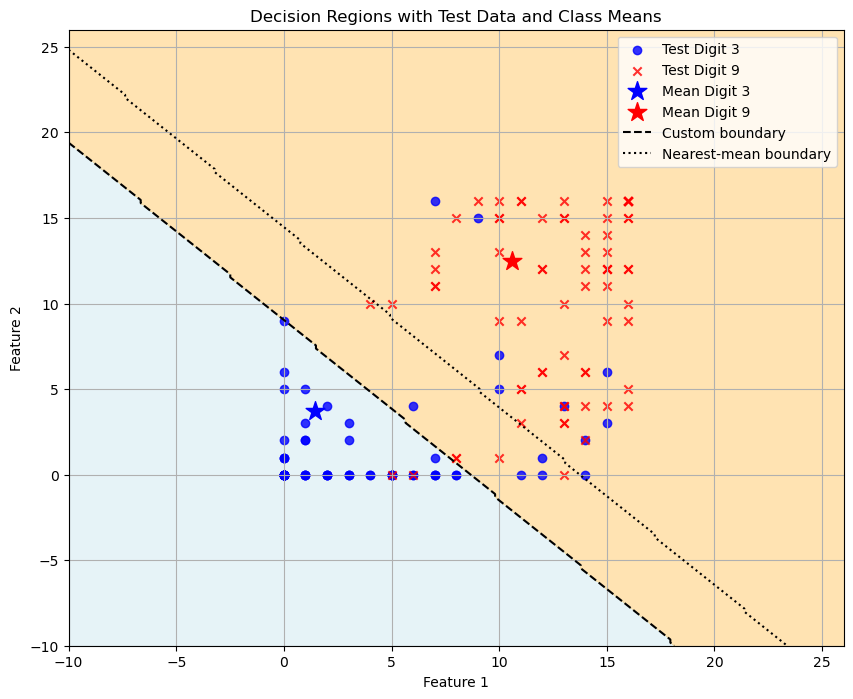

In [150]:
grid_size = 200

# eX_trainact each feature column
f1 = training_features[:, 0]
f2 = training_features[:, 1]

# find min and max for each feature separately
min_f1_raw = f1.min()
max_f1_raw = f1.max()
min_f2_raw = f2.min()
max_f2_raw = f2.max()

# add padding
min_f1 = min_f1_raw - 10
max_f1 = max_f1_raw + 10
min_f2 = min_f2_raw - 10
max_f2 = max_f2_raw + 10

# create the grid with the grid_size 200
f1_vals = np.linspace(min_f1, max_f1, grid_size)
f2_vals = np.linspace(min_f2, max_f2, grid_size)
F1, F2 = np.meshgrid(f1_vals, f2_vals)

# stack F1 and F2 into two columns but they should be flatten (output will have a shape of (40,000, 2))
grid_features = np.column_stack([F1.ravel(), F2.ravel()])

# predict using both classifiers for the grid
predict_custom_classifier = custom_classifier(grid_features, beta, b).reshape(F1.shape)
predict_nearest_mean = nearest_mean(training_features, y_train_changed, grid_features).reshape(F1.shape)

# plot the decision regions
plt.figure(figsize=(10, 8))
plt.contourf(F1, F2, predict_custom_classifier, levels=[-1, 0, 1], colors=['lightblue', 'orange'], alpha=0.3)

# plot decision boundary lines for both classifiers
plt.contour(F1, F2, predict_custom_classifier, levels=[0], colors='black', linestyles='--')
plt.contour(F1, F2, predict_nearest_mean, levels=[0], colors='black', linestyles=':')

# overlay test data on the grid regions
mask3_test = np.isin(y_test_changed, -1)
mask9_test = np.isin(y_test_changed, 1)

f1_test3 = test_features[mask3_test, 0]
f2_test3 = test_features[mask3_test, 1]
f1_test9 = test_features[mask9_test, 0]
f2_test9 = test_features[mask9_test, 1]

plt.scatter(f1_test3, f2_test3, label='Test Digit 3', marker='o', color='blue', alpha=0.8)
plt.scatter(f1_test9, f2_test9, label='Test Digit 9', marker='x', color='red', alpha=0.8)

# plot class means
mask3 = np.isin(y_train_changed, -1)
mask9 = np.isin(y_train_changed, 1)

mean3 = training_features[mask3].mean(axis=0)
mean9 = training_features[mask9].mean(axis=0)

plt.scatter(mean3[0], mean3[1], label='Mean Digit 3', marker='*', s=200, color='blue')
plt.scatter(mean9[0], mean9[1], label='Mean Digit 9', marker='*', s=200, color='red')

# for our decision boundaries exist in the legend
plt.plot([], [], color='black', linestyle='--', label='Custom boundary')
plt.plot([], [], color='black', linestyle=':', label='Nearest-mean boundary')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Regions with Test Data and Class Means')
plt.legend()
plt.grid()
plt.show()


### 3 LDA
#### 3.1 Implement LDA training

In [151]:
def fit_lda(X, y):
    # use the formula/algorithm that fits the cluster means and covmat matrix
    mask_minus1 = np.isin(y, -1)
    mask_plus1 = np.isin(y, 1)

    X_minus1 = X[mask_minus1]
    X_plus1 = X[mask_plus1]

    n_minus1 = X_minus1.shape[0]
    n_plus1 = X_plus1.shape[0]
    N = n_minus1 + n_plus1

    mu_minus1 = X_minus1.mean(axis=0)
    mu_plus1 = X_plus1.mean(axis=0)
    mu = np.vstack([mu_minus1, mu_plus1])

    # find the shared covmat matrix
    centered_minus1 = X_minus1 - mu_minus1
    centered_plus1 = X_plus1 - mu_plus1
    covmat = (centered_minus1.T @ centered_minus1 + centered_plus1.T @ centered_plus1) / N

    # find the class priors
    prior_minus1 = n_minus1 / N
    prior_plus1 = n_plus1 / N
    p = np.array([prior_minus1, prior_plus1])

    return mu, covmat, p

# 2d features from task 2
X2_train = training_features
X2_test = test_features

# full 64-d features with dead pixels removed
pixel_variance = np.var(data_39, axis=0)
active_pixel_mask = pixel_variance >= 0.001
Xfull_train = X_train[:, active_pixel_mask]
Xfull_test = X_test[:, active_pixel_mask]

mu, covmat, p = fit_lda(X2_train, y_train_changed)
mu_full, covmat_full, p_full = fit_lda(Xfull_train, y_train_changed)

#### 3.2 Implement LDA prediction

In [152]:
def predict_lda(mu, covmat, p, X_input):
    # use the decision rule formula to predict beta and bias
    mu_minus1 = mu[0]
    mu_plus1 = mu[1]

    eps = 1e-6
    covmat_stable = covmat + eps * np.eye(covmat.shape[0])
    covmat_inv = np.linalg.inv(covmat_stable)
    beta = covmat_inv @ (mu_plus1 - mu_minus1)
    bias = -0.5 * ((mu_plus1 + mu_minus1) @ beta) + np.log(p[1] / p[0])

    result = X_input @ beta + bias
    
    predicted_labels = []
    for item in result:
        if item >= 0:
            predicted_labels.append(1)
        else:
            predicted_labels.append(-1)
    return np.array(predicted_labels)


predicted_labels_lda_train = predict_lda(mu, covmat, p, X2_train)
predicted_labels_lda_test = predict_lda(mu, covmat, p, X2_test)
training_error_lda = compute_error(predicted_labels_lda_train, y_train_changed)
test_error_lda = compute_error(predicted_labels_lda_test, y_test_changed)

predicted_labels_full_train = predict_lda(mu_full, covmat_full, p_full, Xfull_train)
predicted_labels_full_test = predict_lda(mu_full, covmat_full, p_full, Xfull_test)
training_error_full_lda = np.mean(predicted_labels_full_train != y_train_changed)
test_error_full_lda = np.mean(predicted_labels_full_test != y_test_changed)

#### 3.3 Visualization

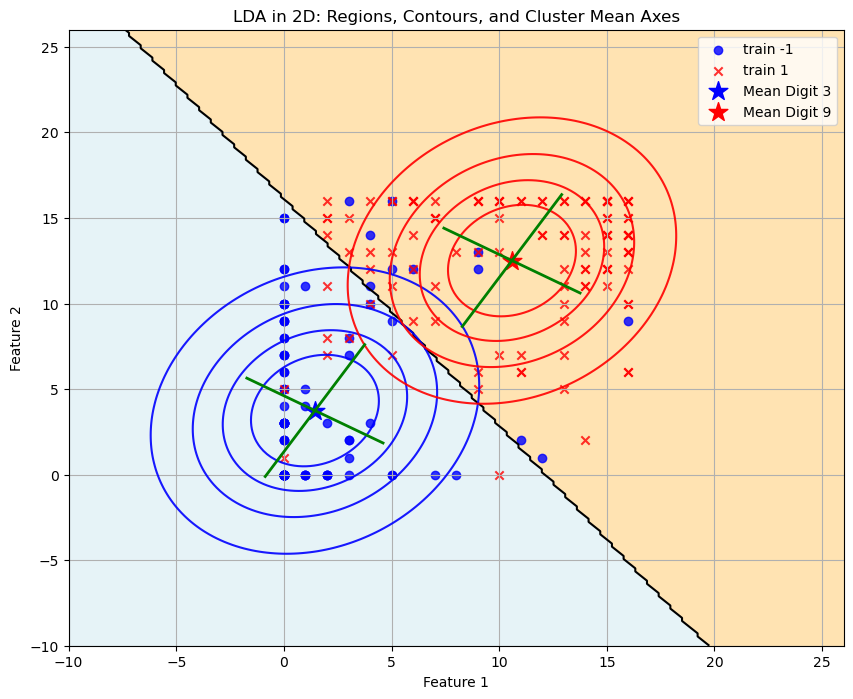

train error: 0.09216589861751152
test error : 0.1095890410958904
train quality: the separation is good on training data
test quality: on test data, the overall prediction looks reasonable


In [153]:
f1 = X2_train[:, 0]
f2 = X2_train[:, 1]

# find min and max for each feature separately
min_f1_raw = f1.min()
max_f1_raw = f1.max()
min_f2_raw = f2.min()
max_f2_raw = f2.max()

# add padding
min_f1 = min_f1_raw - 10
max_f1 = max_f1_raw + 10
min_f2 = min_f2_raw - 10
max_f2 = max_f2_raw + 10

# create the grid with the grid_size 200 which we already declared in task 2.4
f1_vals = np.linspace(min_f1, max_f1, grid_size)
f2_vals = np.linspace(min_f2, max_f2, grid_size)
F1, F2 = np.meshgrid(f1_vals, f2_vals)

# stack F1 and F2 into two columns but they should be flatten (output will have a shape of (40,000, 2))
grid_features = np.column_stack([F1.ravel(), F2.ravel()])

predicted_grid_labels = predict_lda(mu, covmat, p, grid_features).reshape(F1.shape)

# find the gaussian density so that we can plot an ellipse which visualizes the cluster shape
def gaussian_density(grid_points, mu_value, covmat_matrix):
    covmat_inv = np.linalg.inv(covmat_matrix)
    covmat_det = np.linalg.det(covmat_matrix)
    centered_points = grid_points - mu_value
    quadratic_form = np.einsum('ij,jk,ik->i', centered_points, covmat_inv, centered_points)
    normalization = 1.0 / (2 * np.pi * np.sqrt(covmat_det))
    return normalization * np.exp(-0.5 * quadratic_form)

density_minus1 = gaussian_density(grid_features, mu[0], covmat).reshape(F1.shape)
density_plus1  = gaussian_density(grid_features, mu[1], covmat).reshape(F1.shape)

# find the eigenvalues and eigenvectors which indicate the cluster radiuses along each axis
eigenvalues, eigenvectors = np.linalg.eig(covmat)
cluster_mean_axis_lengths = np.sqrt(np.maximum(eigenvalues, 0))

# plot the decision regions
plt.figure(figsize=(10, 8))
plt.contourf(F1, F2, predicted_grid_labels, levels=[-1, 0, 1], colors=['lightblue', 'orange'], alpha=0.3)
plt.contour(F1, F2, predicted_grid_labels, levels=[0], colors='black')

# overlay the train data on the 200x200 grid
mask3 = np.isin(y_train_changed, -1)
mask9 = np.isin(y_train_changed,  1)
plt.scatter(X2_train[mask3, 0], X2_train[mask3, 1], label='train -1', marker='o', color='blue', alpha=0.8)
plt.scatter(X2_train[mask9, 0], X2_train[mask9, 1], label='train 1',  marker='x', color='red',  alpha=0.8)

# plot the class means
mean3 = X2_train[mask3].mean(axis=0)
mean9 = X2_train[mask9].mean(axis=0)
plt.scatter(mean3[0], mean3[1], label='Mean Digit 3', marker='*', s=200, color='blue')
plt.scatter(mean9[0], mean9[1], label='Mean Digit 9', marker='*', s=200, color='red')

# plot the gaussian density contours
levels_minus1 = np.linspace(density_minus1.max() * 0.15, density_minus1.max() * 0.75, 4)
levels_plus1  = np.linspace(density_plus1.max()  * 0.15, density_plus1.max()  * 0.75, 4)
plt.contour(F1, F2, density_minus1, levels=levels_minus1, colors='blue', alpha=0.9)
plt.contour(F1, F2, density_plus1,  levels=levels_plus1,  colors='red',  alpha=0.9)

# find and plot the axes that centered at the cluster mean 
for mu_value in [mu[0], mu[1]]:
    for k in range(2):
        principal_vector = eigenvectors[:, k].real
        axis_length = cluster_mean_axis_lengths[k].real
        axis_start = mu_value - axis_length * principal_vector
        axis_end   = mu_value + axis_length * principal_vector
        plt.plot([axis_start[0], axis_end[0]], [axis_start[1], axis_end[1]], color='green', linewidth=2)

plt.title('LDA in 2D: Regions, Contours, and Cluster Mean Axes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid()
plt.show()

print('train error:', training_error_lda)
print('test error :', test_error_lda)
if training_error_lda < 0.15:
    print('train quality: the separation is good on training data')
else:
    print('train quality: too much overlap is still visible on training data')

if test_error_lda < 0.20:
    print('test quality: on test data, the overall prediction looks reasonable')
else:
    print('test quality: generalization is weak, there is noticeable overlap')

#### 3.4 Quantitative performance evaluation

In [154]:
# perform a 10 fold cross validation on all available data on digits 3 and 9 only
# compare the results with the results from the official LDA implementation in the sklearn package
X_all = data_39[:, active_pixel_mask]
y_all = np.where(target_39 == 3, -1, 1)

folds = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

custom_cv_errors  = []
sklearn_cv_errors = []

for train_idx, test_idx in folds.split(X_all, y_all):
    X_train, X_test = X_all[train_idx], X_all[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]

    mu_cv, cov_cv, p_cv = fit_lda(X_train, y_train)
    predict_cv = predict_lda(mu_cv, cov_cv, p_cv, X_test)
    custom_cv_errors.append(compute_error(predict_cv, y_test))

    sklearn_lda = LinearDiscriminantAnalysis(solver='svd')
    sklearn_lda.fit(X_train, y_train)
    predict_sklearn = sklearn_lda.predict(X_test)
    sklearn_cv_errors.append(compute_error(predict_sklearn, y_test))

custom_cv_errors  = np.array(custom_cv_errors)
sklearn_cv_errors = np.array(sklearn_cv_errors)

print("LDA mean error:", custom_cv_errors.mean())
print("LDA standard deviation: ", custom_cv_errors.std())
print("Sklearn mean error:", sklearn_cv_errors.mean())
print("Sklearn standard deviation: ", sklearn_cv_errors.std())
print("we can say based on the error, our model predicts for labels reasonably well")

LDA mean error: 0.01096096096096096
LDA standard deviation:  0.013426479823488383
Sklearn mean error: 0.01096096096096096
Sklearn standard deviation:  0.013426479823488383
we can say based on the error, our model predicts for labels reasonably well


### 4 SVM